In [12]:
import numpy as np
from pathlib import Path

SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
]
LABELS = ["03/03","03/04","03/05","03/09","03/10"]

print("=== Reach z-PSTH grid per session ===")
for sf, lab in zip(SESSION_ANALYSIS_FOLDERS, LABELS):
    fp = dict(np.load(Path(sf) / "fingerprints" / "unit_fingerprints.npz",
                      allow_pickle=True))
    centers_path = Path(sf) / "qc" / "reach_good_in_trial_arrays.npz"
    if fp["has_reach"]:
        nb = fp["reach_z_mean"].shape[1]
    else:
        nb = "no reach"
    if centers_path.exists():
        c = np.load(centers_path)["centers"]
        print(f"  {lab}: fp bins={nb} | centers n={len(c)}, "
              f"range={c[0]:+.2f} → {c[-1]:+.2f}s, bin_size={c[1]-c[0]:.3f}s")
    else:
        print(f"  {lab}: fp bins={nb} | no centers file")

=== Reach z-PSTH grid per session ===
  03/03: fp bins=300 | centers n=300, range=-1.99 → +3.99s, bin_size=0.020s
  03/04: fp bins=300 | centers n=300, range=-1.99 → +3.99s, bin_size=0.020s
  03/05: fp bins=300 | centers n=300, range=-1.99 → +3.99s, bin_size=0.020s
  03/09: fp bins=300 | centers n=300, range=-1.99 → +3.99s, bin_size=0.020s
  03/10: fp bins=300 | centers n=300, range=-1.99 → +3.99s, bin_size=0.020s


In [13]:
# ============================================================
# CELL X — CROSS-DAY UNIT MATCHING (PAIRWISE, N-session)
# ============================================================
# For each pair of sessions: computes match scores between all
# units, applies conservative hard filters, ranks candidates, and
# enforces bijection (mutual best-match). Already N-session: it
# loops over all pairs of whatever is in SESSION_ANALYSIS_FOLDERS.
# Output: matched_pairs_{sessionA}__vs__{sessionB}.npz per pair.
# ============================================================
import json
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr
from itertools import combinations

print("\n===== CELL X — CROSS-DAY UNIT MATCHING =====")

# ------------------------------------------------------------
# USER EDIT — sessions to compare
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
]

# Conservative hard filter thresholds
MAX_CENTROID_DIST_UM    = 30.0
MAX_LOG_RATE_DIFF       = 0.3
MIN_WAVEFORM_CORR       = 0.85
MIN_ACG_CORR            = 0.5

# Soft scoring weights
W_WAVEFORM = 3.0; W_ACG = 2.0; W_RATE = 1.0
W_WIDTH = 1.0; W_BURST = 1.0; W_REACH = 2.0

MIN_MATCH_SCORE = 0.65
OUTPUT_BASE = r"G:\Kevin\unit_matching"
# ------------------------------------------------------------

output_base = Path(OUTPUT_BASE)
output_base.mkdir(exist_ok=True, parents=True)

def load_fingerprints(session_folder):
    fp_path = Path(session_folder) / "fingerprints" / "unit_fingerprints.npz"
    if not fp_path.exists():
        raise FileNotFoundError(f"No fingerprint at {fp_path}")
    fp = dict(np.load(fp_path, allow_pickle=True))
    fp["session_name"] = Path(session_folder).name
    fp["session_folder"] = str(session_folder)
    return fp

session_fps = []
for sf in SESSION_ANALYSIS_FOLDERS:
    print(f"\nLoading: {Path(sf).name}")
    fp = load_fingerprints(sf)
    print(f"  Units: {len(fp['unit_ids'])} | bursts: {bool(fp['has_bursts'])} "
          f"| reach: {bool(fp['has_reach'])}")
    session_fps.append(fp)

# ------------------------------------------------------------
# MATCHING FUNCTIONS
# ------------------------------------------------------------
def centroid_distance(fp_a, fp_b, i, j):
    dx = fp_a["centroid_x"][i] - fp_b["centroid_x"][j]
    dy = fp_a["centroid_y"][i] - fp_b["centroid_y"][j]
    return float(np.sqrt(dx**2 + dy**2))

def log_rate_diff(fp_a, fp_b, i, j):
    ra = max(fp_a["firing_rate"][i], 1e-6); rb = max(fp_b["firing_rate"][j], 1e-6)
    return abs(np.log(ra / rb))

def waveform_correlation(fp_a, fp_b, i, j):
    wa = fp_a["waveform_best"][i]; wb = fp_b["waveform_best"][j]
    if wa.std() == 0 or wb.std() == 0: return 0.0
    return float(pearsonr(wa, wb)[0])

def acg_correlation(fp_a, fp_b, i, j):
    aa = fp_a["acg"][i]; ab = fp_b["acg"][j]
    if aa.std() == 0 or ab.std() == 0: return 0.0
    return float(pearsonr(aa, ab)[0])

def rate_similarity(fp_a, fp_b, i, j):
    return max(0.0, 1 - log_rate_diff(fp_a, fp_b, i, j) / MAX_LOG_RATE_DIFF)

def width_similarity(fp_a, fp_b, i, j):
    return max(0.0, 1 - abs(fp_a["width_ms"][i] - fp_b["width_ms"][j]) / 1.0)

def burst_similarity(fp_a, fp_b, i, j):
    if not (fp_a["has_bursts"] and fp_b["has_bursts"]): return None
    return max(0.0, 1 - abs(fp_a["burst_fraction"][i] - fp_b["burst_fraction"][j]) / 0.05)

def reach_similarity(fp_a, fp_b, i, j):
    if not (fp_a["has_reach"] and fp_b["has_reach"]): return None
    if not (fp_a["reach_modulated"][i] and fp_b["reach_modulated"][j]): return None
    za = fp_a["reach_z_mean"][i]; zb = fp_b["reach_z_mean"][j]
    if len(za) != len(zb): return None
    if za.std() == 0 or zb.std() == 0: return 0.0
    return max(0.0, float(pearsonr(za, zb)[0]))

def compute_match_score(fp_a, fp_b, i, j):
    wr = waveform_correlation(fp_a, fp_b, i, j)
    ar = acg_correlation(fp_a, fp_b, i, j)
    rs = rate_similarity(fp_a, fp_b, i, j)
    ws = width_similarity(fp_a, fp_b, i, j)
    bs = burst_similarity(fp_a, fp_b, i, j)
    rch = reach_similarity(fp_a, fp_b, i, j)
    wsum = W_WAVEFORM*wr + W_ACG*ar + W_RATE*rs + W_WIDTH*ws
    msum = W_WAVEFORM + W_ACG + W_RATE + W_WIDTH
    if bs is not None: wsum += W_BURST*bs; msum += W_BURST
    if rch is not None: wsum += W_REACH*rch; msum += W_REACH
    return {"score": wsum/msum if msum > 0 else 0.0,
            "waveform_r": wr, "acg_r": ar, "rate_similarity": rs,
            "width_similarity": ws, "burst_similarity": bs, "reach_similarity": rch}

def match_session_pair(fp_a, fp_b):
    n_a = len(fp_a["unit_ids"]); n_b = len(fp_b["unit_ids"])
    score_matrix = np.zeros((n_a, n_b))
    filter_passed = np.zeros((n_a, n_b), dtype=bool)
    all_metrics = {}
    print(f"  Scoring {n_a} × {n_b} pairs...")
    for i in range(n_a):
        for j in range(n_b):
            if centroid_distance(fp_a, fp_b, i, j) > MAX_CENTROID_DIST_UM: continue
            if log_rate_diff(fp_a, fp_b, i, j) > MAX_LOG_RATE_DIFF: continue
            if waveform_correlation(fp_a, fp_b, i, j) < MIN_WAVEFORM_CORR: continue
            if acg_correlation(fp_a, fp_b, i, j) < MIN_ACG_CORR: continue
            m = compute_match_score(fp_a, fp_b, i, j)
            score_matrix[i, j] = m["score"]; filter_passed[i, j] = True
            all_metrics[(i, j)] = m
    matches = []
    for i in range(n_a):
        if not filter_passed[i].any(): continue
        best_j = int(np.argmax(score_matrix[i]))
        if score_matrix[i, best_j] < MIN_MATCH_SCORE: continue
        if int(np.argmax(score_matrix[:, best_j])) != i: continue   # reciprocity
        m = all_metrics[(i, best_j)]
        matches.append({
            "session_a_unit": int(fp_a["unit_ids"][i]),
            "session_b_unit": int(fp_b["unit_ids"][best_j]),
            "session_a_idx": int(i), "session_b_idx": int(best_j),
            "score": float(score_matrix[i, best_j]),
            "centroid_distance_um": centroid_distance(fp_a, fp_b, i, best_j),
            "log_rate_diff": log_rate_diff(fp_a, fp_b, i, best_j),
            "waveform_r": m["waveform_r"], "acg_r": m["acg_r"],
            "rate_similarity": m["rate_similarity"], "width_similarity": m["width_similarity"],
            "burst_similarity": m["burst_similarity"] if m["burst_similarity"] is not None else -1,
            "reach_similarity": m["reach_similarity"] if m["reach_similarity"] is not None else -1,
        })
    return matches, score_matrix, filter_passed

# ------------------------------------------------------------
# RUN ALL PAIRWISE COMPARISONS
# ------------------------------------------------------------
all_results = {}
for idx_a, idx_b in combinations(range(len(session_fps)), 2):
    fp_a, fp_b = session_fps[idx_a], session_fps[idx_b]
    name_a, name_b = fp_a["session_name"], fp_b["session_name"]
    pair_key = f"{name_a}__vs__{name_b}"
    print(f"\n--- Matching {name_a} ↔ {name_b} ---")
    matches, score_matrix, filter_passed = match_session_pair(fp_a, fp_b)
    print(f"  Pairs passing hard filters: {filter_passed.sum()}")
    print(f"  Mutual best matches: {len(matches)}")
    if matches:
        sc = [m["score"] for m in matches]
        print(f"  Score range: {min(sc):.3f} → {max(sc):.3f}, median {np.median(sc):.3f}")
    out_path = output_base / f"matched_pairs_{pair_key}.npz"
    if matches:
        np.savez(out_path,
            session_a_units=np.array([m["session_a_unit"] for m in matches]),
            session_b_units=np.array([m["session_b_unit"] for m in matches]),
            session_a_idx=np.array([m["session_a_idx"] for m in matches]),
            session_b_idx=np.array([m["session_b_idx"] for m in matches]),
            scores=np.array([m["score"] for m in matches]),
            centroid_distances=np.array([m["centroid_distance_um"] for m in matches]),
            log_rate_diffs=np.array([m["log_rate_diff"] for m in matches]),
            waveform_rs=np.array([m["waveform_r"] for m in matches]),
            acg_rs=np.array([m["acg_r"] for m in matches]),
            rate_similarities=np.array([m["rate_similarity"] for m in matches]),
            width_similarities=np.array([m["width_similarity"] for m in matches]),
            burst_similarities=np.array([m["burst_similarity"] for m in matches]),
            reach_similarities=np.array([m["reach_similarity"] for m in matches]),
            session_a_name=np.array(name_a), session_b_name=np.array(name_b),
            session_a_folder=np.array(fp_a["session_folder"]),
            session_b_folder=np.array(fp_b["session_folder"]))
        print(f"  Saved → {out_path.name}")
    else:
        print(f"  No matches found.")
    all_results[pair_key] = {"n_matches": len(matches)}

print("\n===== MATCHING SUMMARY =====")
print(f"{'Comparison':<60} {'Matches':>10}")
print("-" * 72)
for pk, r in all_results.items():
    print(f"{pk[:58]:<60} {r['n_matches']:>10d}")

with open(output_base / "matching_summary.json", "w") as f:
    json.dump({"criteria": {"max_centroid_dist_um": MAX_CENTROID_DIST_UM,
        "max_log_rate_diff": MAX_LOG_RATE_DIFF, "min_waveform_corr": MIN_WAVEFORM_CORR,
        "min_acg_corr": MIN_ACG_CORR, "min_match_score": MIN_MATCH_SCORE},
        "weights": {"waveform": W_WAVEFORM, "acg": W_ACG, "rate": W_RATE,
        "width": W_WIDTH, "burst": W_BURST, "reach": W_REACH},
        "results": {k: v["n_matches"] for k, v in all_results.items()}}, f, indent=2)
print("\n===== CELL X COMPLETE =====\n")


===== CELL X — CROSS-DAY UNIT MATCHING =====

Loading: 2026-03-03_10-26-01_experiment1_recording1_analysis
  Units: 40 | bursts: True | reach: True

Loading: 2026-03-04_08-31-33_experiment1_recording1_analysis
  Units: 100 | bursts: True | reach: True

Loading: 2026-03-05_09-27-03_experiment2_recording1_analysis
  Units: 192 | bursts: True | reach: True

Loading: 2026-03-09_14-29-25_experiment2_recording1_analysis
  Units: 185 | bursts: True | reach: True

Loading: 2026-03-10_13-58-34_experiment1_recording1_analysis
  Units: 87 | bursts: True | reach: True

--- Matching 2026-03-03_10-26-01_experiment1_recording1_analysis ↔ 2026-03-04_08-31-33_experiment1_recording1_analysis ---
  Scoring 40 × 100 pairs...
  Pairs passing hard filters: 12
  Mutual best matches: 8
  Score range: 0.735 → 0.850, median 0.829
  Saved → matched_pairs_2026-03-03_10-26-01_experiment1_recording1_analysis__vs__2026-03-04_08-31-33_experiment1_recording1_analysis.npz

--- Matching 2026-03-03_10-26-01_experiment1_

In [14]:
# ============================================================
# CELL Y — VISUAL VALIDATION OF MATCHED UNIT PAIRS (N-session)
# ============================================================
# For each pair of sessions, produces a PDF of the top-N matched
# pairs with: waveforms, ACGs, reach z-PSTHs, probe-position overlay,
# and a numerical-comparison table. Handles cross-session PSTHs with
# different window/bin settings (bin-index x-axis + warning).
# Already N-session: loops over all pairs in SESSION_ANALYSIS_FOLDERS.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path
from itertools import combinations

print("\n===== CELL Y — MATCHED PAIR VISUALIZATION =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
]
OUTPUT_BASE = r"G:\Kevin\unit_matching"
N_TOP_TO_PLOT = 30   # plot the top-N matches by score per pair
# ------------------------------------------------------------

output_base = Path(OUTPUT_BASE)

# ------------------------------------------------------------
# LOAD FINGERPRINTS
# ------------------------------------------------------------
session_fps = []
for sf in SESSION_ANALYSIS_FOLDERS:
    fp_path = Path(sf) / "fingerprints" / "unit_fingerprints.npz"
    fp = dict(np.load(fp_path, allow_pickle=True))
    fp["session_name"] = Path(sf).name
    fp["session_folder"] = str(sf)
    session_fps.append(fp)
print(f"Loaded {len(session_fps)} session fingerprints")

# ------------------------------------------------------------
# PLOT ONE MATCHED PAIR
# ------------------------------------------------------------
def plot_matched_pair(fp_a, fp_b, idx_a, idx_b, match_info, pair_idx, n_pairs):
    """Side-by-side comparison of two matched units."""
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.35)

    unit_a = int(fp_a["unit_ids"][idx_a])
    unit_b = int(fp_b["unit_ids"][idx_b])

    title = (f"Match {pair_idx+1}/{n_pairs}: "
             f"{fp_a['session_name'][:20]} unit {unit_a} ↔ "
             f"{fp_b['session_name'][:20]} unit {unit_b}\n"
             f"score={match_info['score']:.3f}  |  "
             f"centroid_dist={match_info['centroid_distance_um']:.1f} µm  |  "
             f"waveform_r={match_info['waveform_r']:.3f}  |  "
             f"acg_r={match_info['acg_r']:.3f}")
    fig.suptitle(title, fontsize=10, y=0.99)

    # --- Waveforms ---
    ax_wf = fig.add_subplot(gs[0, :2])
    wf_a = fp_a["waveform_best"][idx_a]
    wf_b = fp_b["waveform_best"][idx_b]
    t_ms_a = np.arange(len(wf_a)) / fp_a["sample_rate_hz"] * 1000
    t_ms_b = np.arange(len(wf_b)) / fp_b["sample_rate_hz"] * 1000
    ax_wf.plot(t_ms_a, wf_a, color="C3", lw=1.5,
               label=f"{fp_a['session_name'][:15]}: unit {unit_a}")
    ax_wf.plot(t_ms_b, wf_b, color="C0", lw=1.5,
               label=f"{fp_b['session_name'][:15]}: unit {unit_b}")
    ax_wf.axhline(0, color="gray", lw=0.5)
    ax_wf.set_title("Waveforms (best channel)", fontsize=10)
    ax_wf.set_xlabel("Time (ms)"); ax_wf.set_ylabel("Amplitude")
    ax_wf.legend(fontsize=8)

    # --- Autocorrelograms ---
    ax_acg = fig.add_subplot(gs[0, 2:])
    ac_a = fp_a["acg"][idx_a]; ac_b = fp_b["acg"][idx_b]
    bin_size_ms = 1.0
    lags_a = np.arange(len(ac_a)) * bin_size_ms
    lags_b = np.arange(len(ac_b)) * bin_size_ms
    ax_acg.plot(lags_a, ac_a, color="C3", lw=1.5,
                label=f"{fp_a['session_name'][:15]}: unit {unit_a}")
    ax_acg.plot(lags_b, ac_b, color="C0", lw=1.5,
                label=f"{fp_b['session_name'][:15]}: unit {unit_b}")
    ax_acg.set_xlabel("Lag (ms)"); ax_acg.set_ylabel("Probability")
    ax_acg.set_title(f"Autocorrelograms (r={match_info['acg_r']:.3f})", fontsize=10)
    ax_acg.legend(fontsize=8)

    # --- Reach PSTH (handles mismatched lengths) ---
    ax_reach = fig.add_subplot(gs[1, :2])
    if fp_a["has_reach"] and fp_b["has_reach"]:
        a_mod = fp_a["reach_modulated"][idx_a]
        b_mod = fp_b["reach_modulated"][idx_b]
        z_a = fp_a["reach_z_mean"][idx_a]
        z_b = fp_b["reach_z_mean"][idx_b]

        centers_path_a = Path(fp_a["session_folder"]) / "qc" / "reach_good_in_trial_arrays.npz"
        centers_a = (np.load(centers_path_a)["centers"]
                     if centers_path_a.exists() else np.arange(len(z_a)))
        centers_path_b = Path(fp_b["session_folder"]) / "qc" / "reach_good_in_trial_arrays.npz"
        centers_b = (np.load(centers_path_b)["centers"]
                     if centers_path_b.exists() else np.arange(len(z_b)))

        if len(z_a) != len(z_b):
            # Different window/bin settings -- use bin indices
            ax_reach.plot(np.arange(len(z_a)), z_a, color="C3", lw=1.5,
                          label=f"{fp_a['session_name'][:15]} "
                                f"({'mod' if a_mod else 'unmod'}, peak {fp_a['reach_peak_z'][idx_a]:.1f}z)")
            ax_reach.plot(np.arange(len(z_b)), z_b, color="C0", lw=1.5,
                          label=f"{fp_b['session_name'][:15]} "
                                f"({'mod' if b_mod else 'unmod'}, peak {fp_b['reach_peak_z'][idx_b]:.1f}z)")
            ax_reach.set_xlabel("Bin index")
            ax_reach.text(0.02, 0.95,
                          "different windows; x-axis is bin index",
                          transform=ax_reach.transAxes, fontsize=7, color="orange",
                          verticalalignment="top")
        else:
            ax_reach.plot(centers_a, z_a, color="C3", lw=1.5,
                          label=f"{fp_a['session_name'][:15]} "
                                f"({'mod' if a_mod else 'unmod'}, peak {fp_a['reach_peak_z'][idx_a]:.1f}z)")
            ax_reach.plot(centers_b, z_b, color="C0", lw=1.5,
                          label=f"{fp_b['session_name'][:15]} "
                                f"({'mod' if b_mod else 'unmod'}, peak {fp_b['reach_peak_z'][idx_b]:.1f}z)")
            ax_reach.axvline(0, color="black", lw=0.5, linestyle="--")
            ax_reach.set_xlabel("Time from reach (s)")

        ax_reach.axhline(0, color="gray", lw=0.5)
        reach_r = match_info["reach_similarity"]
        title_str = "Reach-aligned z-PSTH"
        if reach_r > 0:
            title_str += f" (r={reach_r:.3f})"
        elif reach_r == -1:
            title_str += " (not comparable across sessions)"
        ax_reach.set_title(title_str, fontsize=10)
        ax_reach.set_ylabel("z-score")
        ax_reach.legend(fontsize=8)
    else:
        ax_reach.text(0.5, 0.5, "No reach data available",
                      ha="center", va="center", transform=ax_reach.transAxes)
        ax_reach.set_xticks([]); ax_reach.set_yticks([])

    # --- Channel position overlay ---
    ax_pos = fig.add_subplot(gs[1, 2:])
    ch_pos = fp_a["channel_positions"]
    ax_pos.scatter(ch_pos[:, 0], ch_pos[:, 1], s=8, color="lightgray",
                   alpha=0.6, label="channels")
    ax_pos.scatter([fp_a["centroid_x"][idx_a]],
                   [fp_a["centroid_y"][idx_a]],
                   s=200, marker="o", color="C3", edgecolor="black",
                   label=f"{fp_a['session_name'][:15]}: ch {fp_a['best_ch'][idx_a]}")
    ax_pos.scatter([fp_b["centroid_x"][idx_b]],
                   [fp_b["centroid_y"][idx_b]],
                   s=200, marker="^", color="C0", edgecolor="black",
                   label=f"{fp_b['session_name'][:15]}: ch {fp_b['best_ch'][idx_b]}")
    ax_pos.set_xlabel("X (µm)"); ax_pos.set_ylabel("Y (µm)")
    ax_pos.set_title(f"Probe position (dist={match_info['centroid_distance_um']:.1f} µm)",
                     fontsize=10)
    ax_pos.legend(fontsize=8); ax_pos.set_aspect("equal")
    cx = (fp_a["centroid_x"][idx_a] + fp_b["centroid_x"][idx_b]) / 2
    cy = (fp_a["centroid_y"][idx_a] + fp_b["centroid_y"][idx_b]) / 2
    ax_pos.set_xlim(cx - 80, cx + 80); ax_pos.set_ylim(cy - 100, cy + 100)

    # --- Numerical comparison table ---
    ax_stats = fig.add_subplot(gs[2, :])
    ax_stats.axis("off")
    rows = [
        ("Metric", f"{fp_a['session_name'][:18]}", f"{fp_b['session_name'][:18]}", "Δ / similarity"),
        ("Unit ID", str(unit_a), str(unit_b), "—"),
        ("Best ch", str(fp_a["best_ch"][idx_a]), str(fp_b["best_ch"][idx_b]),
         f"Δ = {int(fp_a['best_ch'][idx_a]) - int(fp_b['best_ch'][idx_b])}"),
        ("Firing rate (Hz)", f"{fp_a['firing_rate'][idx_a]:.2f}",
         f"{fp_b['firing_rate'][idx_b]:.2f}",
         f"log-ratio = {match_info['log_rate_diff']:.3f}"),
        ("Waveform width (ms)", f"{fp_a['width_ms'][idx_a]:.2f}",
         f"{fp_b['width_ms'][idx_b]:.2f}",
         f"sim = {match_info['width_similarity']:.3f}"),
        ("Peak-to-peak amp", f"{fp_a['peak_to_peak_amp'][idx_a]:.2f}",
         f"{fp_b['peak_to_peak_amp'][idx_b]:.2f}", "—"),
        ("ISI CV", f"{fp_a['isi_cv'][idx_a]:.2f}",
         f"{fp_b['isi_cv'][idx_b]:.2f}", "—"),
    ]
    if fp_a["has_bursts"] and fp_b["has_bursts"]:
        rows.append(("Burst fraction (%)", f"{fp_a['burst_fraction'][idx_a]*100:.2f}",
                     f"{fp_b['burst_fraction'][idx_b]*100:.2f}",
                     f"sim = {match_info['burst_similarity']:.3f}"
                     if match_info['burst_similarity'] >= 0 else "—"))
        rows.append(("Burst rate (Hz)", f"{fp_a['burst_rate'][idx_a]:.3f}",
                     f"{fp_b['burst_rate'][idx_b]:.3f}", "—"))
    table = ax_stats.table(cellText=rows[1:], colLabels=rows[0],
                           loc="center", cellLoc="center",
                           colColours=["lightgray"] * 4)
    table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.6)

    return fig

# ------------------------------------------------------------
# PROCESS EACH PAIR
# ------------------------------------------------------------
n_total_plots = 0
for idx_a, idx_b in combinations(range(len(session_fps)), 2):
    fp_a = session_fps[idx_a]; fp_b = session_fps[idx_b]
    name_a = fp_a["session_name"]; name_b = fp_b["session_name"]
    pair_key = f"{name_a}__vs__{name_b}"

    matches_path = output_base / f"matched_pairs_{pair_key}.npz"
    if not matches_path.exists():
        print(f"\nNo matches file for {pair_key} (run Cell X first?)")
        continue

    matches_data = np.load(matches_path, allow_pickle=True)
    n_matches = len(matches_data["scores"])
    print(f"\n--- {pair_key} ---")
    print(f"  Total matches: {n_matches}")
    if n_matches == 0:
        continue

    order = np.argsort(matches_data["scores"])[::-1][:N_TOP_TO_PLOT]

    pdf_path = output_base / f"validation_{pair_key}.pdf"
    with PdfPages(pdf_path) as pdf:
        for plot_i, m_idx in enumerate(order):
            match_info = {
                "score": float(matches_data["scores"][m_idx]),
                "centroid_distance_um": float(matches_data["centroid_distances"][m_idx]),
                "log_rate_diff": float(matches_data["log_rate_diffs"][m_idx]),
                "waveform_r": float(matches_data["waveform_rs"][m_idx]),
                "acg_r": float(matches_data["acg_rs"][m_idx]),
                "rate_similarity": float(matches_data["rate_similarities"][m_idx]),
                "width_similarity": float(matches_data["width_similarities"][m_idx]),
                "burst_similarity": float(matches_data["burst_similarities"][m_idx]),
                "reach_similarity": float(matches_data["reach_similarities"][m_idx]),
            }
            idx_a_match = int(matches_data["session_a_idx"][m_idx])
            idx_b_match = int(matches_data["session_b_idx"][m_idx])
            fig = plot_matched_pair(fp_a, fp_b, idx_a_match, idx_b_match,
                                    match_info, plot_i, min(n_matches, N_TOP_TO_PLOT))
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
            n_total_plots += 1
    print(f"  Saved → {pdf_path.name}")

print(f"\nTotal validation plots: {n_total_plots}")
print("\n===== CELL Y COMPLETE =====\n")


===== CELL Y — MATCHED PAIR VISUALIZATION =====
Loaded 5 session fingerprints

--- 2026-03-03_10-26-01_experiment1_recording1_analysis__vs__2026-03-04_08-31-33_experiment1_recording1_analysis ---
  Total matches: 8
  Saved → validation_2026-03-03_10-26-01_experiment1_recording1_analysis__vs__2026-03-04_08-31-33_experiment1_recording1_analysis.pdf

--- 2026-03-03_10-26-01_experiment1_recording1_analysis__vs__2026-03-05_09-27-03_experiment2_recording1_analysis ---
  Total matches: 14
  Saved → validation_2026-03-03_10-26-01_experiment1_recording1_analysis__vs__2026-03-05_09-27-03_experiment2_recording1_analysis.pdf

--- 2026-03-03_10-26-01_experiment1_recording1_analysis__vs__2026-03-09_14-29-25_experiment2_recording1_analysis ---
  Total matches: 14
  Saved → validation_2026-03-03_10-26-01_experiment1_recording1_analysis__vs__2026-03-09_14-29-25_experiment2_recording1_analysis.pdf

--- 2026-03-03_10-26-01_experiment1_recording1_analysis__vs__2026-03-10_13-58-34_experiment1_recording1_a

In [15]:
# ============================================================
# CELL Z (N-SESSION) — UNITS TRACKED ACROSS MULTIPLE SESSIONS
# ============================================================
# Generalizes the old 3-session triple-bijection to ANY number
# of sessions. Builds a graph of all pairwise matches, finds
# connected components that are CONSISTENT (at most one unit per
# session per component), and reports units tracked across all N,
# and across each smaller depth (N-1, N-2, ... 2).
#
# Reads Cell X's matched_pairs_{A}__vs__{B}.npz files.
# Output:
#   - tracked_units_chains.npz   (one row per tracked unit-chain)
#   - tracked_units_across_sessions.pdf (one page per all-N unit)
# ============================================================
import json
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

print("\n===== CELL Z (N-SESSION) — UNITS TRACKED ACROSS SESSIONS =====")

# ------------------------------------------------------------
# USER EDIT — list ALL sessions in the order you want them indexed
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
]
SESSION_LABELS = ["03/03", "03/04", "03/05", "03/09", "03/10"]   # short labels, same order
OUTPUT_BASE = r"G:\Kevin\unit_matching"
MIN_DEPTH_TO_REPORT = 2   # report chains spanning >= this many sessions
# ------------------------------------------------------------

output_base = Path(OUTPUT_BASE)
n_sessions = len(SESSION_ANALYSIS_FOLDERS)

# ------------------------------------------------------------
# LOAD FINGERPRINTS
# ------------------------------------------------------------
session_names, session_fps = [], []
for sf in SESSION_ANALYSIS_FOLDERS:
    fp = dict(np.load(Path(sf) / "fingerprints" / "unit_fingerprints.npz",
                      allow_pickle=True))
    fp["session_name"] = Path(sf).name
    fp["session_folder"] = str(sf)
    session_names.append(Path(sf).name)
    session_fps.append(fp)
print(f"Loaded {n_sessions} session fingerprints")
for i, name in enumerate(session_names):
    print(f"  S{i} ({SESSION_LABELS[i]}): {name} ({len(session_fps[i]['unit_ids'])} units)")

# ------------------------------------------------------------
# LOAD ALL PAIRWISE MATCH FILES (both filename orderings)
# ------------------------------------------------------------
def load_pair(i, j):
    """Load matches between session i and j; returns {unit_i: (unit_j, score)} and reverse."""
    for a, b, flip in [(i, j, False), (j, i, True)]:
        path = output_base / f"matched_pairs_{session_names[a]}__vs__{session_names[b]}.npz"
        if path.exists():
            d = np.load(path, allow_pickle=True)
            ua = d["session_a_units"]; ub = d["session_b_units"]; sc = d["scores"]
            if flip:  # file is j-vs-i, so swap so keys are session i
                ua, ub = ub, ua
            fwd = {int(x): (int(y), float(s)) for x, y, s in zip(ua, ub, sc)}
            return fwd
    return {}

# pair_match[(i,j)] = {unit_i: (unit_j, score)} for i < j
pair_match = {}
pair_counts = {}
for i, j in itertools.combinations(range(n_sessions), 2):
    m = load_pair(i, j)
    pair_match[(i, j)] = m
    pair_counts[(i, j)] = len(m)

print("\nPairwise match counts:")
for (i, j), c in pair_counts.items():
    flag = "" if c > 0 else "   <-- MISSING/empty (run Cell X for this pair?)"
    print(f"  S{i} ({SESSION_LABELS[i]}) ↔ S{j} ({SESSION_LABELS[j]}): {c} matches{flag}")

# ------------------------------------------------------------
# BUILD A GRAPH OF MATCHES AND FIND CONSISTENT CHAINS
# ------------------------------------------------------------
# Node = (session_index, unit_id). Edge = a pairwise match.
# A "chain" = connected component. We keep it only if it has
# AT MOST ONE node per session (a consistent identity).
# ------------------------------------------------------------
from collections import defaultdict

adj = defaultdict(list)          # node -> list of (node, score)
for (i, j), m in pair_match.items():
    for ui, (uj, sc) in m.items():
        a = (i, ui); b = (j, uj)
        adj[a].append((b, sc))
        adj[b].append((a, sc))

visited = set()
chains = []
for start in list(adj.keys()):
    if start in visited:
        continue
    # BFS to gather connected component
    comp = []
    stack = [start]
    comp_edges = []
    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        comp.append(node)
        for nb, sc in adj[node]:
            comp_edges.append((node, nb, sc))
            if nb not in visited:
                stack.append(nb)

    # group nodes by session
    by_sess = defaultdict(list)
    for (s, u) in comp:
        by_sess[s].append(u)

    # CONSISTENCY: at most one unit per session
    consistent = all(len(v) == 1 for v in by_sess.values())
    depth = len(by_sess)

    chain = {
        "nodes": comp,
        "by_session": {s: v[0] for s, v in by_sess.items()} if consistent else dict(by_sess),
        "depth": depth,
        "consistent": consistent,
        "edges": comp_edges,
    }
    chains.append(chain)

# Score each consistent chain = geometric mean of all available pairwise scores among its sessions
def chain_score(chain):
    if not chain["consistent"]:
        return 0.0
    sess = sorted(chain["by_session"].keys())
    scs = []
    for i, j in itertools.combinations(sess, 2):
        ui = chain["by_session"][i]
        m = pair_match.get((i, j), {})
        if ui in m and m[ui][0] == chain["by_session"][j]:
            scs.append(m[ui][1])
    if not scs:
        return 0.0
    return float(np.exp(np.mean(np.log(scs))))  # geometric mean

for ch in chains:
    ch["score"] = chain_score(ch)

# Keep consistent chains spanning >= MIN_DEPTH_TO_REPORT sessions
tracked = [c for c in chains if c["consistent"] and c["depth"] >= MIN_DEPTH_TO_REPORT]
tracked.sort(key=lambda c: (c["depth"], c["score"]), reverse=True)

# Report inconsistent components (identity conflicts) for transparency
inconsistent = [c for c in chains if not c["consistent"] and c["depth"] >= MIN_DEPTH_TO_REPORT]

# ------------------------------------------------------------
# REPORT BY DEPTH
# ------------------------------------------------------------
print(f"\n===== TRACKED CHAINS BY DEPTH =====")
for d in range(n_sessions, MIN_DEPTH_TO_REPORT - 1, -1):
    at_d = [c for c in tracked if c["depth"] == d]
    sess_word = "ALL " if d == n_sessions else ""
    print(f"  Tracked across {sess_word}{d} sessions: {len(at_d)}")
if inconsistent:
    print(f"  (Excluded {len(inconsistent)} inconsistent components "
          f"with identity conflicts — see note below)")

all_n = [c for c in tracked if c["depth"] == n_sessions]
print(f"\n  >>> Units present in ALL {n_sessions} sessions: {len(all_n)} <<<")

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
# Build a rectangular table: one row per tracked chain, columns = unit id per session (-1 if absent)
rows_units = np.full((len(tracked), n_sessions), -1, dtype=int)
for r, ch in enumerate(tracked):
    for s, u in ch["by_session"].items():
        rows_units[r, s] = u
depths = np.array([c["depth"] for c in tracked])
scores = np.array([c["score"] for c in tracked])

np.savez(
    output_base / "tracked_units_chains.npz",
    units_by_session=rows_units,     # (n_chains, n_sessions), -1 = not present
    depth=depths,
    score=scores,
    session_names=np.array(session_names),
    session_labels=np.array(SESSION_LABELS),
)
print(f"\nSaved → tracked_units_chains.npz "
      f"({len(tracked)} chains, columns = {SESSION_LABELS})")

# ------------------------------------------------------------
# VISUALIZATION — one PDF page per ALL-N tracked unit
# ------------------------------------------------------------
def get_unit_idx(fp, unit_id):
    return int(np.where(fp["unit_ids"] == unit_id)[0][0])

colors = plt.cm.viridis(np.linspace(0, 0.85, n_sessions))

if all_n:
    pdf_path = output_base / "tracked_units_across_sessions.pdf"
    print(f"\nGenerating PDF for {len(all_n)} all-{n_sessions}-session units...")
    with PdfPages(pdf_path) as pdf:
        for ci, ch in enumerate(all_n):
            sess_order = sorted(ch["by_session"].keys())
            idxs = {s: get_unit_idx(session_fps[s], ch["by_session"][s]) for s in sess_order}

            fig = plt.figure(figsize=(15, 10))
            gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

            unit_str = ", ".join(f"{SESSION_LABELS[s]}:u{ch['by_session'][s]}" for s in sess_order)
            fig.suptitle(f"All-{n_sessions} tracked unit #{ci+1}/{len(all_n)} "
                         f"(score {ch['score']:.3f})\n{unit_str}", fontsize=11)

            # waveforms
            ax = fig.add_subplot(gs[0, 0])
            for s in sess_order:
                wf = session_fps[s]["waveform_best"][idxs[s]]
                t_ms = np.arange(len(wf)) / session_fps[s]["sample_rate_hz"] * 1000
                ax.plot(t_ms, wf, color=colors[s], lw=1.6, label=SESSION_LABELS[s])
            ax.axhline(0, color="gray", lw=0.5); ax.set_title("Waveforms")
            ax.set_xlabel("ms"); ax.legend(fontsize=8)

            # ACGs
            ax = fig.add_subplot(gs[0, 1])
            for s in sess_order:
                acg = session_fps[s]["acg"][idxs[s]]
                ax.plot(np.arange(len(acg)), acg, color=colors[s], lw=1.6, label=SESSION_LABELS[s])
            ax.set_title("Autocorrelograms"); ax.set_xlabel("Lag (ms)"); ax.legend(fontsize=8)

            # reach PSTHs
            ax = fig.add_subplot(gs[1, 0])
            any_reach = False
            for s in sess_order:
                if not session_fps[s]["has_reach"]:
                    continue
                z = session_fps[s]["reach_z_mean"][idxs[s]]
                pk = session_fps[s]["reach_peak_z"][idxs[s]]
                md = session_fps[s]["reach_modulated"][idxs[s]]
                ax.plot(np.arange(len(z)), z, color=colors[s], lw=1.6,
                        label=f"{SESSION_LABELS[s]} ({'mod' if md else 'unmod'}, {pk:.1f}z)")
                any_reach = True
            if any_reach:
                ax.axhline(0, color="gray", lw=0.5); ax.set_title("Reach z-PSTH")
                ax.set_xlabel("Bin"); ax.legend(fontsize=8)
            else:
                ax.text(0.5, 0.5, "No reach data", ha="center", transform=ax.transAxes)

            # stats table
            ax = fig.add_subplot(gs[1, 1]); ax.axis("off")
            header = ["Metric"] + [SESSION_LABELS[s] for s in sess_order]
            rows = [
                ["Unit"] + [str(ch["by_session"][s]) for s in sess_order],
                ["Best ch"] + [str(int(session_fps[s]["best_ch"][idxs[s]])) for s in sess_order],
                ["Rate (Hz)"] + [f"{session_fps[s]['firing_rate'][idxs[s]]:.2f}" for s in sess_order],
                ["Width (ms)"] + [f"{session_fps[s]['width_ms'][idxs[s]]:.2f}" for s in sess_order],
            ]
            if all(session_fps[s]["has_reach"] for s in sess_order):
                rows.append(["Reach mod?"] +
                            ["y" if session_fps[s]["reach_modulated"][idxs[s]] else "n"
                             for s in sess_order])
                rows.append(["Reach peak z"] +
                            [f"{session_fps[s]['reach_peak_z'][idxs[s]]:.2f}"
                             for s in sess_order])
            tbl = ax.table(cellText=rows, colLabels=header,
                           loc="center", cellLoc="center",
                           colColours=["lightgray"] * (len(sess_order) + 1))
            tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.6)

            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)
    print(f"Saved → {pdf_path.name}")
else:
    print(f"\nNo units tracked across all {n_sessions} sessions to plot.")

# ------------------------------------------------------------
# NOTE ON INCONSISTENT COMPONENTS
# ------------------------------------------------------------
if inconsistent:
    print(f"\nNOTE: {len(inconsistent)} match components had identity conflicts")
    print(f"  (e.g. unit matched to TWO different units in another session).")
    print(f"  These are excluded from tracked chains. A few are normal; many")
    print(f"  suggest the match threshold (MIN_MATCH_SCORE) is too lenient.")

print("\n===== CELL Z (N-SESSION) COMPLETE =====\n")


===== CELL Z (N-SESSION) — UNITS TRACKED ACROSS SESSIONS =====
Loaded 5 session fingerprints
  S0 (03/03): 2026-03-03_10-26-01_experiment1_recording1_analysis (40 units)
  S1 (03/04): 2026-03-04_08-31-33_experiment1_recording1_analysis (100 units)
  S2 (03/05): 2026-03-05_09-27-03_experiment2_recording1_analysis (192 units)
  S3 (03/09): 2026-03-09_14-29-25_experiment2_recording1_analysis (185 units)
  S4 (03/10): 2026-03-10_13-58-34_experiment1_recording1_analysis (87 units)

Pairwise match counts:
  S0 (03/03) ↔ S1 (03/04): 8 matches
  S0 (03/03) ↔ S2 (03/05): 14 matches
  S0 (03/03) ↔ S3 (03/09): 14 matches
  S0 (03/03) ↔ S4 (03/10): 14 matches
  S1 (03/04) ↔ S2 (03/05): 66 matches
  S1 (03/04) ↔ S3 (03/09): 44 matches
  S1 (03/04) ↔ S4 (03/10): 12 matches
  S2 (03/05) ↔ S3 (03/09): 67 matches
  S2 (03/05) ↔ S4 (03/10): 28 matches
  S3 (03/09) ↔ S4 (03/10): 29 matches

===== TRACKED CHAINS BY DEPTH =====
  Tracked across ALL 5 sessions: 1
  Tracked across 4 sessions: 1
  Tracked ac


===== CELL AA (N-SESSION) — LONGITUDINAL REACH PSTH =====
Loaded 81 tracked chains
Units tracked across >= 3 sessions: 33
Saved → longitudinal_reach_trajectories.pdf


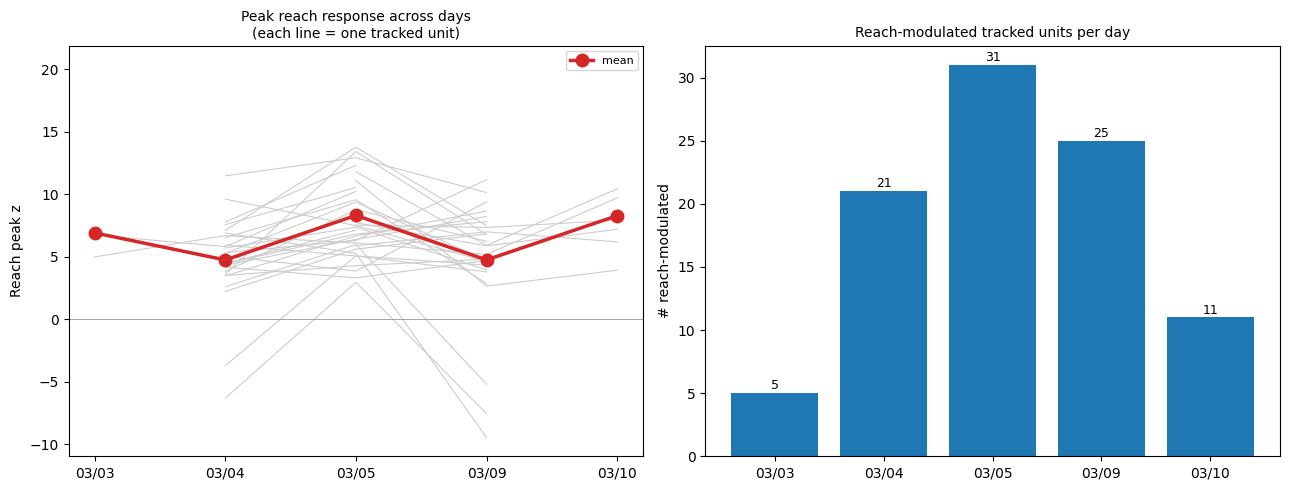

Saved → population_trajectory_summary.png

===== CELL AA (N-SESSION) COMPLETE =====



In [16]:
# ============================================================
# CELL AA (N-SESSION) — LONGITUDINAL REACH PSTH TRAJECTORIES
# ============================================================
# Reads tracked_units_chains.npz from the N-session Cell Z and
# plots each tracked unit's reach PSTH across the sessions it was
# found in. Focuses on units tracked across many sessions; also
# summarizes peak-z trajectories across days.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

print("\n===== CELL AA (N-SESSION) — LONGITUDINAL REACH PSTH =====")

# ------------------------------------------------------------
# USER EDIT — must match Cell Z's session order exactly
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
]
SESSION_LABELS = ["03/03", "03/04", "03/05", "03/09", "03/10"]
OUTPUT_BASE = r"G:\Kevin\unit_matching"
MIN_DEPTH_TO_PLOT = 3   # only plot units tracked across >= this many sessions
# ------------------------------------------------------------

output_base = Path(OUTPUT_BASE)
n_sessions = len(SESSION_ANALYSIS_FOLDERS)

# load chains table from N-session Cell Z
ch = np.load(output_base / "tracked_units_chains.npz", allow_pickle=True)
units_by_session = ch["units_by_session"]   # (n_chains, n_sessions), -1 = absent
depth = ch["depth"]; score = ch["score"]
print(f"Loaded {len(units_by_session)} tracked chains")

session_fps = []
for sf in SESSION_ANALYSIS_FOLDERS:
    fp = dict(np.load(Path(sf) / "fingerprints" / "unit_fingerprints.npz",
                      allow_pickle=True))
    fp["session_folder"] = str(sf)
    session_fps.append(fp)

def get_unit_idx(fp, unit_id):
    hit = np.where(fp["unit_ids"] == unit_id)[0]
    return int(hit[0]) if len(hit) else None

colors = plt.cm.viridis(np.linspace(0, 0.85, n_sessions))

# session bin centers (for x-axis in seconds); fall back to bin index
session_centers = []
for fp in session_fps:
    p = Path(fp["session_folder"]) / "qc" / "reach_good_in_trial_arrays.npz"
    session_centers.append(np.load(p)["centers"] if p.exists() else None)

# ------------------------------------------------------------
# INDIVIDUAL TRAJECTORY PDF (units tracked >= MIN_DEPTH_TO_PLOT)
# ------------------------------------------------------------
plot_rows = [r for r in range(len(units_by_session)) if depth[r] >= MIN_DEPTH_TO_PLOT]
print(f"Units tracked across >= {MIN_DEPTH_TO_PLOT} sessions: {len(plot_rows)}")

pdf_path = output_base / "longitudinal_reach_trajectories.pdf"
peak_z_traj = []
peak_lat_traj = []
mod_matrix = []

with PdfPages(pdf_path) as pdf:
    for r in plot_rows:
        present = [s for s in range(n_sessions) if units_by_session[r, s] >= 0]
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

        pz_row = np.full(n_sessions, np.nan)
        pl_row = np.full(n_sessions, np.nan)
        md_row = np.zeros(n_sessions, dtype=bool)

        for s in present:
            fp = session_fps[s]
            idx = get_unit_idx(fp, units_by_session[r, s])
            if idx is None or not fp["has_reach"]:
                continue
            z = fp["reach_z_mean"][idx]
            x = session_centers[s] if session_centers[s] is not None else np.arange(len(z))
            pk = float(fp["reach_peak_z"][idx]); md = bool(fp["reach_modulated"][idx])
            ax1.plot(x, z, color=colors[s], lw=1.8,
                     label=f"{SESSION_LABELS[s]} ({'mod' if md else 'unmod'}, {pk:.1f}z)")
            pz_row[s] = pk
            if "reach_peak_lat" in fp:
                pl_row[s] = float(fp["reach_peak_lat"][idx])
            md_row[s] = md

        ax1.axhline(0, color="gray", lw=0.5)
        if session_centers[present[0]] is not None:
            ax1.axvline(0, color="black", lw=1, linestyle="--")
            ax1.set_xlabel("Time from reach (s)")
        else:
            ax1.set_xlabel("Bin index")
        ax1.set_ylabel("Reach z-score"); ax1.legend(fontsize=8)
        unit_str = ", ".join(f"{SESSION_LABELS[s]}:u{units_by_session[r,s]}" for s in present)
        ax1.set_title(f"Tracked unit (depth {depth[r]}, score {score[r]:.3f})\n{unit_str}",
                      fontsize=10)

        ax2.plot(range(n_sessions), pz_row, "o-", color="C0", lw=2, markersize=8)
        ax2.set_xticks(range(n_sessions)); ax2.set_xticklabels(SESSION_LABELS, fontsize=9)
        ax2.axhline(0, color="gray", lw=0.5)
        ax2.set_ylabel("Reach peak z"); ax2.set_title("Peak response across days", fontsize=10)

        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)
        peak_z_traj.append(pz_row); peak_lat_traj.append(pl_row); mod_matrix.append(md_row)

print(f"Saved → {pdf_path.name}")

peak_z_traj = np.array(peak_z_traj)
peak_lat_traj = np.array(peak_lat_traj)
mod_matrix = np.array(mod_matrix)

# ------------------------------------------------------------
# POPULATION SUMMARY
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for row in peak_z_traj:
    ax.plot(range(n_sessions), row, color="0.8", lw=0.8)
mean_pz = np.nanmean(peak_z_traj, axis=0)
ax.plot(range(n_sessions), mean_pz, "o-", color="C3", lw=2.5, markersize=9, label="mean")
ax.set_xticks(range(n_sessions)); ax.set_xticklabels(SESSION_LABELS)
ax.axhline(0, color="gray", lw=0.5); ax.set_ylabel("Reach peak z")
ax.set_title("Peak reach response across days\n(each line = one tracked unit)", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
counts = [int(np.nansum(mod_matrix[:, s])) for s in range(n_sessions)]
ax.bar(range(n_sessions), counts, color="C0")
ax.set_xticks(range(n_sessions)); ax.set_xticklabels(SESSION_LABELS)
ax.set_ylabel("# reach-modulated"); ax.set_title("Reach-modulated tracked units per day", fontsize=10)
for i, c in enumerate(counts):
    ax.text(i, c + 0.3, str(c), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(output_base / "population_trajectory_summary.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → population_trajectory_summary.png")
print("\n===== CELL AA (N-SESSION) COMPLETE =====\n")


===== CROSS-DAY EXEMPLAR PICKER (with probe position) =====
Tracked units present in all 3 focus sessions: 22

Top 22 candidates (by summed |peak z| across 3 days):
  #1  [chain_row=8]  Σ|z|= 34.6  max drift=23.3 µm
        S1:u256(+11.5z), S2:u321(+12.9z), S3:u278(+10.2z)
  #2  [chain_row=29]  Σ|z|= 28.4  max drift=26.7 µm
        S1:u150(+7.1z), S2:u169(+13.8z), S3:u144(+7.5z)
  #3  [chain_row=9]  Σ|z|= 23.8  max drift=30.1 µm
        S1:u240(+3.6z), S2:u276(+13.4z), S3:u230(+6.8z)
  #4  [chain_row=26]  Σ|z|= 22.8  max drift=33.5 µm
        S1:u366(+5.3z), S2:u451(+6.3z), S3:u392(+11.2z)
  #5  [chain_row=13]  Σ|z|= 21.8  max drift=37.4 µm
        S1:u248(+9.6z), S2:u311(+7.5z), S3:u282(+4.6z)
  #6  [chain_row=32]  Σ|z|= 21.6  max drift=14.3 µm
        S1:u386(+6.9z), S2:u466(+5.3z), S3:u428(-9.5z)
  #7  [chain_row=25]  Σ|z|= 19.4  max drift=17.3 µm
        S1:u66(+5.3z), S2:u73(+9.4z), S3:u90(+4.7z)
  #8  [chain_row=12]  Σ|z|= 19.1  max drift=22.9 µm
        S1:u279(+4.5z), S2:u333(

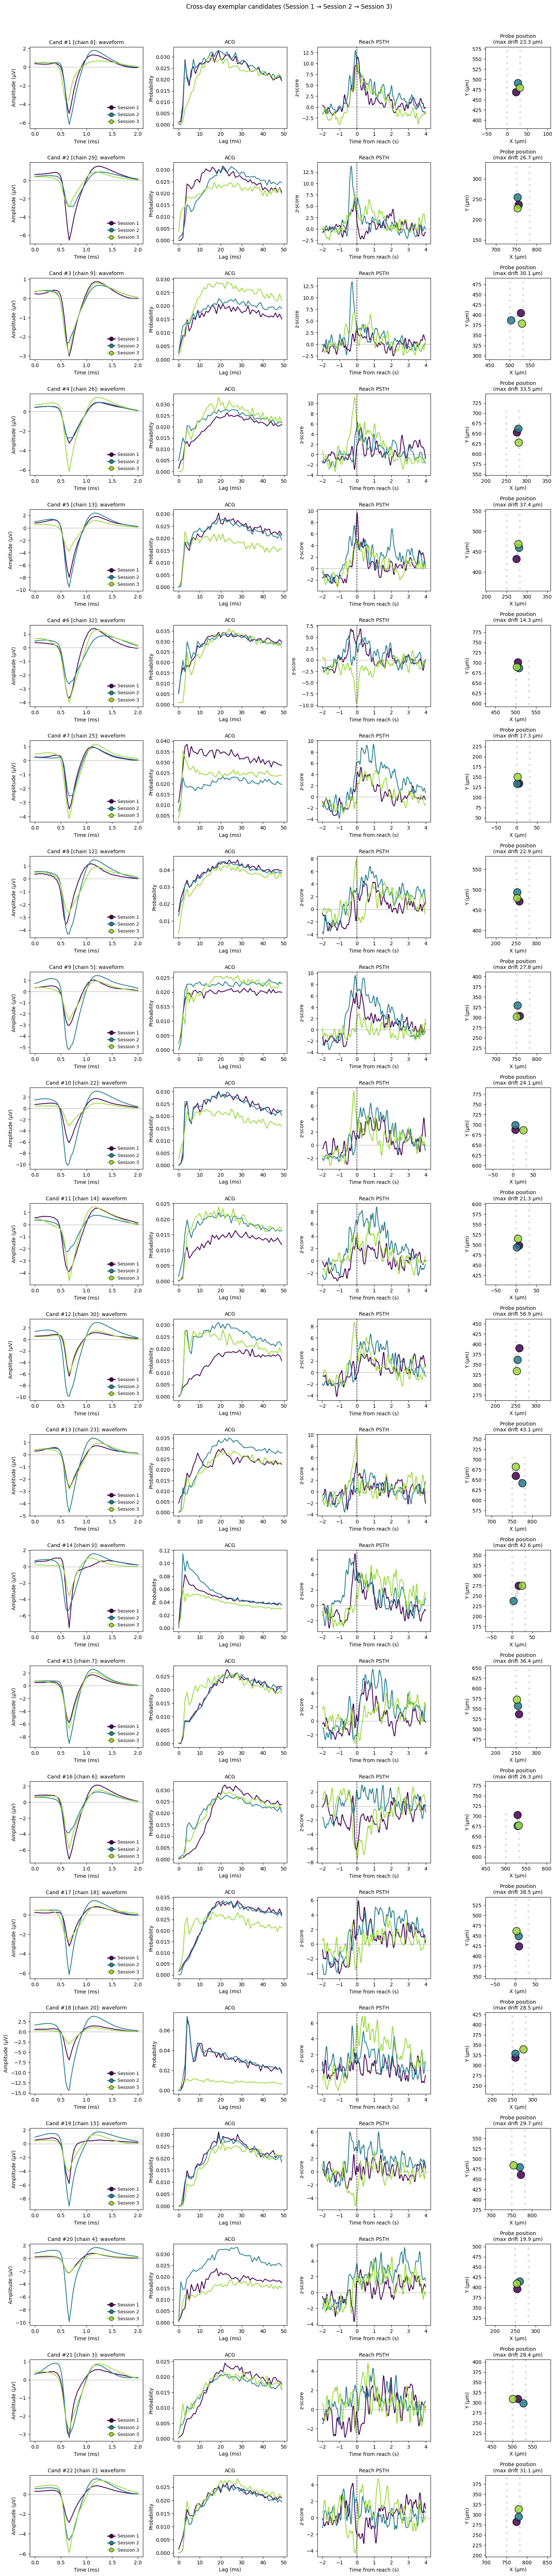


Saving per-unit PDF → D:\Kevin\unit_matching\exemplar_candidates.pdf
  saved page 2 / 23  (Candidate #1)
  saved page 3 / 23  (Candidate #2)
  saved page 4 / 23  (Candidate #3)
  saved page 5 / 23  (Candidate #4)
  saved page 6 / 23  (Candidate #5)
  saved page 7 / 23  (Candidate #6)
  saved page 8 / 23  (Candidate #7)
  saved page 9 / 23  (Candidate #8)
  saved page 10 / 23  (Candidate #9)
  saved page 11 / 23  (Candidate #10)
  saved page 12 / 23  (Candidate #11)
  saved page 13 / 23  (Candidate #12)
  saved page 14 / 23  (Candidate #13)
  saved page 15 / 23  (Candidate #14)
  saved page 16 / 23  (Candidate #15)
  saved page 17 / 23  (Candidate #16)
  saved page 18 / 23  (Candidate #17)
  saved page 19 / 23  (Candidate #18)
  saved page 20 / 23  (Candidate #19)
  saved page 21 / 23  (Candidate #20)
  saved page 22 / 23  (Candidate #21)
  saved page 23 / 23  (Candidate #22)

PDF saved: D:\Kevin\unit_matching\exemplar_candidates.pdf  (23 pages: 1 cover + 22 units)
Pick a candidate (ra

In [3]:
# ============================================================
# CROSS-DAY EXEMPLAR PICKER (with probe position)
# ============================================================
# Ranks tracked units across the chosen focus sessions by summed
# |peak z|. For each top candidate, shows waveform, ACG, reach PSTH,
# AND probe-position overlay so the spatial stability of the unit
# is immediately visible.
#
# OUTPUT: saves a PDF to OUTPUT_BASE / "exemplar_candidates.pdf"
#         one page per unit, in rank order.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from pathlib import Path

print("\n===== CROSS-DAY EXEMPLAR PICKER (with probe position) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"D:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"D:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
]
SESSION_LABELS       = ["Session 1", "Session 2", "Session 3"]   # legend labels
SESSION_LABELS_SHORT = ["S1", "S2", "S3"]                        # console printout
OUTPUT_BASE    = r"D:\Kevin\unit_matching"
PDF_FILENAME   = "exemplar_candidates.pdf"   # saved inside OUTPUT_BASE
N_CANDIDATES   = 22
ZOOM_X_HALF_UM = 80
ZOOM_Y_HALF_UM = 100
# ------------------------------------------------------------

output_base = Path(OUTPUT_BASE)
n_sessions  = len(SESSION_ANALYSIS_FOLDERS)
focus_names = [Path(sf).name for sf in SESSION_ANALYSIS_FOLDERS]

# ------------------------------------------------------------
# LOAD CHAINS, FILTER TO FOCUS SESSIONS
# ------------------------------------------------------------
ch = np.load(output_base / "tracked_units_chains.npz", allow_pickle=True)
all_session_names    = list(ch["session_names"])
units_by_session_full = ch["units_by_session"]

focus_cols = []
for fn in focus_names:
    if fn not in all_session_names:
        raise RuntimeError(f"Session {fn} not in saved chains. Re-run Cell Z including it.")
    focus_cols.append(all_session_names.index(fn))

units_focus_all = units_by_session_full[:, focus_cols]
keep            = (units_focus_all >= 0).all(axis=1)
units_focus     = units_focus_all[keep]
original_rows   = np.where(keep)[0]   # maps filtered index -> chains-table row
print(f"Tracked units present in all {n_sessions} focus sessions: {len(units_focus)}")
if len(units_focus) == 0:
    raise RuntimeError("No units tracked across all focus sessions.")

# ------------------------------------------------------------
# LOAD FINGERPRINTS
# ------------------------------------------------------------
fps = []
for sf in SESSION_ANALYSIS_FOLDERS:
    fp = dict(np.load(Path(sf) / "fingerprints" / "unit_fingerprints.npz",
                      allow_pickle=True))
    fp["session_folder"] = str(sf)
    fps.append(fp)

def uidx(fp, uid):
    return int(np.where(fp["unit_ids"] == uid)[0][0])

centers_per_session = []
for fp in fps:
    p = Path(fp["session_folder"]) / "qc" / "reach_good_in_trial_arrays.npz"
    centers_per_session.append(np.load(p)["centers"])

# ------------------------------------------------------------
# RANK BY SUMMED |PEAK Z|
# ------------------------------------------------------------
rank_score = np.zeros(len(units_focus))
for r in range(len(units_focus)):
    s = 0.0
    for si, fp in enumerate(fps):
        idx = uidx(fp, units_focus[r, si])
        s  += abs(float(fp["reach_peak_z"][idx]))
    rank_score[r] = s
order = np.argsort(rank_score)[::-1]

# ------------------------------------------------------------
# PRINT TOP CANDIDATES
# ------------------------------------------------------------
print(f"\nTop {N_CANDIDATES} candidates (by summed |peak z| across {n_sessions} days):")
for rank, r in enumerate(order[:N_CANDIDATES]):
    chain_row = int(original_rows[r])
    uid_per   = units_focus[r]
    cents = []; pks = []
    for si, fp in enumerate(fps):
        idx = uidx(fp, uid_per[si])
        cents.append((float(fp["centroid_x"][idx]), float(fp["centroid_y"][idx])))
        pks.append(float(fp["reach_peak_z"][idx]))
    max_drift = max(np.hypot(cents[a][0]-cents[b][0], cents[a][1]-cents[b][1])
                    for a in range(n_sessions) for b in range(a+1, n_sessions))
    pk_str = ", ".join(f"{SESSION_LABELS_SHORT[si]}:u{uid_per[si]}({pks[si]:+.1f}z)"
                       for si in range(n_sessions))
    print(f"  #{rank+1}  [chain_row={chain_row}]  Σ|z|={rank_score[r]:5.1f}  "
          f"max drift={max_drift:.1f} µm")
    print(f"        {pk_str}")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
colors = plt.cm.viridis(np.linspace(0, 0.85, n_sessions))

def make_legend_handles():
    """Colored line+dot handle for each session."""
    handles = []
    for si in range(n_sessions):
        h = Line2D([0], [0], color=colors[si], lw=2.2, marker="o",
                   markersize=8, markerfacecolor=colors[si],
                   markeredgecolor="black", markeredgewidth=0.8,
                   label=SESSION_LABELS[si])
        handles.append(h)
    return handles

def plot_unit_page(fig, r, cand_i):
    """
    Fill *fig* (4-panel layout) with data for candidate ranked cand_i.
    r  : index into units_focus (already selected from order[])
    """
    uid_per   = units_focus[r]
    chain_row = int(original_rows[r])
    axes      = fig.subplots(1, 4)

    # Compute per-session values needed for titles
    cxs, cys, pks = [], [], []
    for si, fp in enumerate(fps):
        idx = uidx(fp, uid_per[si])
        cxs.append(float(fp["centroid_x"][idx]))
        cys.append(float(fp["centroid_y"][idx]))
        pks.append(float(fp["reach_peak_z"][idx]))
    max_drift = max(np.hypot(cxs[a]-cxs[b], cys[a]-cys[b])
                    for a in range(n_sessions) for b in range(a+1, n_sessions))

    # ---- Waveform ----
    ax = axes[0]
    for si, fp in enumerate(fps):
        idx = uidx(fp, uid_per[si])
        wf  = fp["waveform_best"][idx]
        t_ms = np.arange(len(wf)) / fp["sample_rate_hz"] * 1000
        ax.plot(t_ms, wf, color=colors[si], lw=1.6)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title("Waveform", fontsize=10)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (µV)")
    ax.legend(handles=make_legend_handles(), fontsize=8,
              loc="lower right", frameon=False,
              handlelength=1.4, handletextpad=0.4, borderpad=0.3)

    # ---- ACG ----
    ax = axes[1]
    for si, fp in enumerate(fps):
        idx = uidx(fp, uid_per[si])
        acg = fp["acg"][idx]
        ax.plot(np.arange(len(acg)), acg, color=colors[si], lw=1.6)
    ax.set_title("ACG", fontsize=10)
    ax.set_xlabel("Lag (ms)")
    ax.set_ylabel("Probability")

    # ---- Reach PSTH ----
    ax = axes[2]
    for si, fp in enumerate(fps):
        idx = uidx(fp, uid_per[si])
        z   = fp["reach_z_mean"][idx]
        x   = centers_per_session[si]
        ax.plot(x, z, color=colors[si], lw=1.6)
    ax.axvline(0, color="black", lw=1, linestyle="--")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("Time from reach (s)")
    ax.set_ylabel("z-score")
    ax.set_title("Reach PSTH", fontsize=10)

    # ---- Probe position ----
    ax = axes[3]
    ch_pos = fps[0]["channel_positions"]
    ax.scatter(ch_pos[:, 0], ch_pos[:, 1], s=10, color="lightgray",
               alpha=0.7, zorder=1)
    for si, fp in enumerate(fps):
        ax.scatter([cxs[si]], [cys[si]], s=220, marker="o", color=colors[si],
                   edgecolor="black", linewidth=1.2, alpha=0.85, zorder=3)
    ax.plot(cxs, cys, color="black", lw=0.8, alpha=0.4, zorder=2)
    mx, my = np.mean(cxs), np.mean(cys)
    ax.set_xlim(mx - ZOOM_X_HALF_UM, mx + ZOOM_X_HALF_UM)
    ax.set_ylim(my - ZOOM_Y_HALF_UM, my + ZOOM_Y_HALF_UM)
    ax.set_aspect("equal")
    ax.set_title(f"Probe position\n(max drift {max_drift:.1f} µm)", fontsize=10)
    ax.set_xlabel("X (µm)")
    ax.set_ylabel("Y (µm)")

    # Page-level super-title
    uid_str = "  |  ".join(
        f"{SESSION_LABELS_SHORT[si]}: u{uid_per[si]} ({pks[si]:+.1f}z)"
        for si in range(n_sessions)
    )
    fig.suptitle(
        f"Candidate #{cand_i+1}  [chain_row={chain_row}]   Σ|z|={rank_score[r]:.1f}\n"
        f"{uid_str}",
        fontsize=10, y=1.02
    )
    fig.tight_layout()

# ------------------------------------------------------------
# INTERACTIVE THUMBNAIL GRID  (unchanged from original)
# ------------------------------------------------------------
n_show = min(N_CANDIDATES, len(units_focus))
fig_grid, axes_grid = plt.subplots(n_show, 4, figsize=(16, 3.2 * n_show))
if n_show == 1:
    axes_grid = axes_grid[np.newaxis, :]

for cand_i, r in enumerate(order[:n_show]):
    uid_per   = units_focus[r]
    chain_row = int(original_rows[r])

    cxs, cys = [], []
    for si, fp in enumerate(fps):
        idx = uidx(fp, uid_per[si])
        cxs.append(float(fp["centroid_x"][idx]))
        cys.append(float(fp["centroid_y"][idx]))

    # Waveform
    ax = axes_grid[cand_i, 0]
    for si, fp in enumerate(fps):
        idx  = uidx(fp, uid_per[si])
        wf   = fp["waveform_best"][idx]
        t_ms = np.arange(len(wf)) / fp["sample_rate_hz"] * 1000
        ax.plot(t_ms, wf, color=colors[si], lw=1.6)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(f"Cand #{cand_i+1} [chain {chain_row}]: waveform", fontsize=10)
    ax.set_xlabel("Time (ms)"); ax.set_ylabel("Amplitude (µV)")
    ax.legend(handles=make_legend_handles(), fontsize=9,
              loc="lower right", frameon=False,
              handlelength=1.6, handletextpad=0.5, borderpad=0.4)

    # ACG
    ax = axes_grid[cand_i, 1]
    for si, fp in enumerate(fps):
        idx = uidx(fp, uid_per[si])
        ax.plot(np.arange(len(fp["acg"][idx])), fp["acg"][idx],
                color=colors[si], lw=1.6)
    ax.set_title("ACG", fontsize=10)
    ax.set_xlabel("Lag (ms)"); ax.set_ylabel("Probability")

    # Reach PSTH
    ax = axes_grid[cand_i, 2]
    for si, fp in enumerate(fps):
        idx = uidx(fp, uid_per[si])
        ax.plot(centers_per_session[si], fp["reach_z_mean"][idx],
                color=colors[si], lw=1.6)
    ax.axvline(0, color="black", lw=1, linestyle="--")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("Time from reach (s)"); ax.set_ylabel("z-score")
    ax.set_title("Reach PSTH", fontsize=10)

    # Probe position
    ax = axes_grid[cand_i, 3]
    ch_pos = fps[0]["channel_positions"]
    ax.scatter(ch_pos[:, 0], ch_pos[:, 1], s=10, color="lightgray",
               alpha=0.7, zorder=1)
    for si, fp in enumerate(fps):
        ax.scatter([cxs[si]], [cys[si]], s=220, marker="o", color=colors[si],
                   edgecolor="black", linewidth=1.2, alpha=0.85, zorder=3)
    ax.plot(cxs, cys, color="black", lw=0.8, alpha=0.4, zorder=2)
    mx, my = np.mean(cxs), np.mean(cys)
    ax.set_xlim(mx - ZOOM_X_HALF_UM, mx + ZOOM_X_HALF_UM)
    ax.set_ylim(my - ZOOM_Y_HALF_UM, my + ZOOM_Y_HALF_UM)
    ax.set_aspect("equal")
    max_drift = max(np.hypot(cxs[a]-cxs[b], cys[a]-cys[b])
                    for a in range(n_sessions) for b in range(a+1, n_sessions))
    ax.set_title(f"Probe position\n(max drift {max_drift:.1f} µm)", fontsize=10)
    ax.set_xlabel("X (µm)"); ax.set_ylabel("Y (µm)")

fig_grid.suptitle(
    f"Cross-day exemplar candidates ({' → '.join(SESSION_LABELS)})",
    fontsize=12, y=1.005)
fig_grid.tight_layout()
plt.show()

# ------------------------------------------------------------
# SAVE PDF  — one page per candidate unit
# ------------------------------------------------------------
pdf_path = output_base / PDF_FILENAME
print(f"\nSaving per-unit PDF → {pdf_path}")

with PdfPages(pdf_path) as pdf:
    # Cover page: summary table
    fig_cover, ax_cover = plt.subplots(figsize=(11, 8.5))
    ax_cover.axis("off")
    header = ["Rank", "chain_row", "Σ|z|", "max drift (µm)",
              *[f"{sl} unit (z)" for sl in SESSION_LABELS_SHORT]]
    rows = []
    for rank, r in enumerate(order[:n_show]):
        chain_row = int(original_rows[r])
        uid_per   = units_focus[r]
        cxs, cys, pks = [], [], []
        for si, fp in enumerate(fps):
            idx = uidx(fp, uid_per[si])
            cxs.append(float(fp["centroid_x"][idx]))
            cys.append(float(fp["centroid_y"][idx]))
            pks.append(float(fp["reach_peak_z"][idx]))
        max_drift = max(np.hypot(cxs[a]-cxs[b], cys[a]-cys[b])
                        for a in range(n_sessions) for b in range(a+1, n_sessions))
        row = [f"#{rank+1}", str(chain_row), f"{rank_score[r]:.1f}",
               f"{max_drift:.1f}",
               *[f"u{uid_per[si]} ({pks[si]:+.1f})" for si in range(n_sessions)]]
        rows.append(row)

    tbl = ax_cover.table(
        cellText=rows, colLabels=header,
        loc="center", cellLoc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.4)
    ax_cover.set_title(
        f"Cross-day exemplar candidates\n"
        f"{' → '.join(SESSION_LABELS)}   |   top {n_show} by Σ|peak z|",
        fontsize=12, pad=16
    )
    pdf.savefig(fig_cover, bbox_inches="tight")
    plt.close(fig_cover)

    # One page per unit
    for cand_i, r in enumerate(order[:n_show]):
        fig_unit = plt.figure(figsize=(16, 4))
        plot_unit_page(fig_unit, r, cand_i)
        pdf.savefig(fig_unit, bbox_inches="tight")
        plt.close(fig_unit)
        print(f"  saved page {cand_i + 2} / {n_show + 1}  (Candidate #{cand_i+1})")

    # PDF metadata
    d = pdf.infodict()
    d["Title"]   = "Cross-day exemplar candidates"
    d["Author"]  = "Exemplar picker script"
    d["Subject"] = f"{' → '.join(SESSION_LABELS)}"

print(f"\nPDF saved: {pdf_path}  ({n_show + 1} pages: 1 cover + {n_show} units)")
print("Pick a candidate (rank or chain_row). Tell me which one and I'll")
print("build the final figure around it.")
print("===== EXEMPLAR PICKER COMPLETE =====\n")


===== CROSS-DAY PEAK-LATENCY FIGURE =====
Tracked units present in all 3 focus sessions: 22
Exemplars to plot: [8, 26, 25, 22]


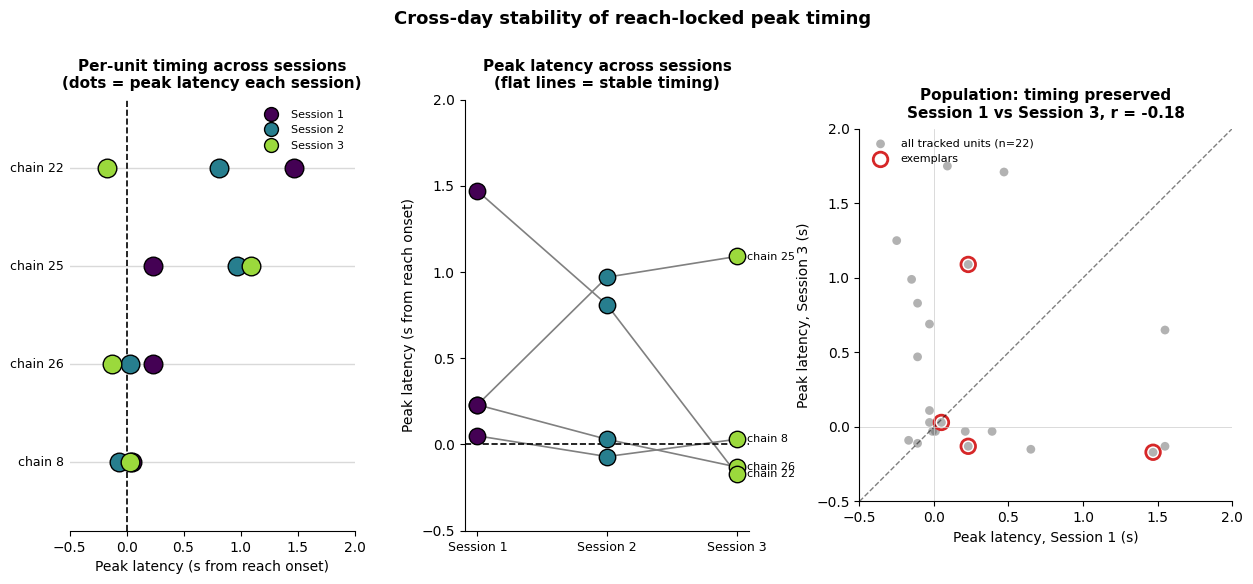


Saved → GRANT_peak_latency_3views.png/.pdf/.svg

===== Exemplar peak latencies =====
 chain   Session 1   Session 2   Session 3
     8      +0.050      -0.070      +0.030
    26      +0.230      +0.030      -0.130
    25      +0.230      +0.970      +1.090
    22      +1.470      +0.810      -0.170

Population (all tracked, n=22):
  Session 1 vs Session 3 Pearson r = -0.180
  Mean |Δlatency| Session 1 → Session 3: 684 ms

===== DONE =====



In [6]:
# ============================================================
# CROSS-DAY PEAK-LATENCY FIGURE — 3 VIEWS
# ============================================================
# Sub-figure 1: Lifelines (per-unit horizontal rows, dots = peak latency
#               on each session)
# Sub-figure 2: Slope plot (per-unit, three connected dots across sessions
#               on a shared latency axis)
# Sub-figure 3: Population session-vs-session scatter of peak latency
#               (all tracked units present in both sessions of the pair)
#
# Exemplars: specify chain row indices in EXEMPLAR_CHAIN_ROWS.
# Population scatter uses ALL tracked units present in the relevant pair.
# Peak latency comes from fp["reach_peak_lat"] (trial-averaged, Cell M-v3).
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from pathlib import Path

print("\n===== CROSS-DAY PEAK-LATENCY FIGURE =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
]
SESSION_LABELS = ["Session 1", "Session 2", "Session 3"]
OUTPUT_BASE = r"G:\Kevin\unit_matching"

# Chain row indices from the exemplar picker — manual list
EXEMPLAR_CHAIN_ROWS = [8, 26, 25, 22]   # add more, e.g. [8, 12, 47, ...]

# Restrict y-axis range for lifelines / slopes (peak latency window)
T_MIN, T_MAX = -0.5, 2.0    # matches Cell M-v3 RESPONSE_WIN
# ------------------------------------------------------------

output_base = Path(OUTPUT_BASE)
n_sessions = len(SESSION_ANALYSIS_FOLDERS)
focus_names = [Path(sf).name for sf in SESSION_ANALYSIS_FOLDERS]
colors = plt.cm.viridis(np.linspace(0, 0.85, n_sessions))

# ------------------------------------------------------------
# LOAD CHAINS
# ------------------------------------------------------------
ch = np.load(output_base / "tracked_units_chains.npz", allow_pickle=True)
all_session_names = list(ch["session_names"])
units_by_session_full = ch["units_by_session"]

focus_cols = []
for fn in focus_names:
    if fn not in all_session_names:
        raise RuntimeError(f"Session {fn} not in saved chains. Re-run Cell Z.")
    focus_cols.append(all_session_names.index(fn))

units_focus_all = units_by_session_full[:, focus_cols]
keep_mask = (units_focus_all >= 0).all(axis=1)
print(f"Tracked units present in all {n_sessions} focus sessions: {keep_mask.sum()}")

# ------------------------------------------------------------
# LOAD FINGERPRINTS
# ------------------------------------------------------------
fps = []
for sf in SESSION_ANALYSIS_FOLDERS:
    fp = dict(np.load(Path(sf) / "fingerprints" / "unit_fingerprints.npz",
                      allow_pickle=True))
    fp["session_folder"] = str(sf)
    fps.append(fp)

def uidx(fp, uid):
    return int(np.where(fp["unit_ids"] == uid)[0][0])

# ------------------------------------------------------------
# COLLECT PER-UNIT PEAK LATENCIES (all tracked units present in all focus sessions)
# ------------------------------------------------------------
all_tracked_rows = np.where(keep_mask)[0]
peak_lat_all = np.full((len(all_tracked_rows), n_sessions), np.nan)
peak_z_all   = np.full((len(all_tracked_rows), n_sessions), np.nan)
for i, ch_row in enumerate(all_tracked_rows):
    for si, fp in enumerate(fps):
        uid = int(units_by_session_full[ch_row, focus_cols[si]])
        idx = uidx(fp, uid)
        peak_lat_all[i, si] = float(fp["reach_peak_lat"][idx])
        peak_z_all[i, si]   = float(fp["reach_peak_z"][idx])

# Exemplars: same data, filtered to chosen chain rows
ex_rows = [r for r in EXEMPLAR_CHAIN_ROWS if r in set(all_tracked_rows.tolist())]
missing = [r for r in EXEMPLAR_CHAIN_ROWS if r not in set(all_tracked_rows.tolist())]
if missing:
    print(f"WARNING: chain rows not present in all focus sessions, dropped: {missing}")
print(f"Exemplars to plot: {ex_rows}")

ex_idx_in_all = np.array([np.where(all_tracked_rows == r)[0][0] for r in ex_rows])
peak_lat_ex = peak_lat_all[ex_idx_in_all]   # (n_exemplars, n_sessions)
peak_z_ex   = peak_z_all[ex_idx_in_all]
ex_uids = np.array([[int(units_by_session_full[r, focus_cols[si]])
                     for si in range(n_sessions)] for r in ex_rows])

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
n_ex = len(ex_rows)
fig = plt.figure(figsize=(15, 4.2 + 0.35 * max(n_ex, 1)))
gs = GridSpec(1, 3, width_ratios=[1.3, 1.3, 1.7], wspace=0.35)

# ---------- View 1: LIFELINES ----------
ax1 = fig.add_subplot(gs[0, 0])
for ui, ch_row in enumerate(ex_rows):
    y = ui
    # horizontal "lifeline"
    ax1.plot([T_MIN, T_MAX], [y, y], color="0.85", lw=1, zorder=1)
    for si in range(n_sessions):
        ax1.scatter([peak_lat_ex[ui, si]], [y],
                    s=180, color=colors[si], edgecolor="black",
                    linewidth=1.0, zorder=3)
    ax1.text(T_MIN - 0.05, y, f"chain {ch_row}", fontsize=9,
             ha="right", va="center")
ax1.axvline(0, color="black", lw=1.2, linestyle="--", zorder=2)
ax1.set_xlim(T_MIN, T_MAX)
ax1.set_ylim(-0.7, n_ex - 0.3)
ax1.set_yticks([])
ax1.set_xlabel("Peak latency (s from reach onset)")
ax1.set_title("Per-unit timing across sessions\n(dots = peak latency each session)",
              fontsize=11, fontweight="bold", pad=8)
ax1.spines[["top", "right", "left"]].set_visible(False)

# Legend (one row, top of panel)
handles = [Line2D([0], [0], marker="o", color="w",
                  markerfacecolor=colors[si], markeredgecolor="black",
                  markersize=10, label=SESSION_LABELS[si])
           for si in range(n_sessions)]
ax1.legend(handles=handles, fontsize=8, loc="upper right",
           frameon=False, ncol=1)

# ---------- View 2: SLOPE PLOT ----------
ax2 = fig.add_subplot(gs[0, 1])
for ui, ch_row in enumerate(ex_rows):
    # connect the three peak latencies across session index (x)
    ax2.plot(range(n_sessions), peak_lat_ex[ui], "-",
             color="0.5", lw=1.2, zorder=1)
    for si in range(n_sessions):
        ax2.scatter([si], [peak_lat_ex[ui, si]],
                    s=140, color=colors[si], edgecolor="black",
                    linewidth=1.0, zorder=3)
    # right-side label
    ax2.text(n_sessions - 1 + 0.08, peak_lat_ex[ui, -1],
             f"chain {ch_row}", fontsize=8, va="center")
ax2.axhline(0, color="black", lw=1.2, linestyle="--", zorder=2)
ax2.set_xticks(range(n_sessions))
ax2.set_xticklabels(SESSION_LABELS, fontsize=9)
ax2.set_ylim(T_MIN, T_MAX)
ax2.set_ylabel("Peak latency (s from reach onset)")
ax2.set_title("Peak latency across sessions\n(flat lines = stable timing)",
              fontsize=11, fontweight="bold", pad=8)
ax2.spines[["top", "right"]].set_visible(False)

# ---------- View 3: POPULATION SESSION-VS-SESSION SCATTER ----------
# show one representative pair: session 1 vs session 3 (longest gap)
ax3 = fig.add_subplot(gs[0, 2])
sa, sb = 0, n_sessions - 1
x = peak_lat_all[:, sa]
y = peak_lat_all[:, sb]
ax3.scatter(x, y, s=40, color="0.4", alpha=0.5, edgecolor="none",
            label=f"all tracked units (n={len(x)})")
# highlight exemplars
ax3.scatter(peak_lat_ex[:, sa], peak_lat_ex[:, sb],
            s=110, facecolor="none", edgecolor="C3",
            linewidth=2.0, label="exemplars")
# diagonal
ax3.plot([T_MIN, T_MAX], [T_MIN, T_MAX], "k--", lw=1, alpha=0.5)
ax3.axvline(0, color="0.8", lw=0.5)
ax3.axhline(0, color="0.8", lw=0.5)
ax3.set_xlim(T_MIN, T_MAX)
ax3.set_ylim(T_MIN, T_MAX)
ax3.set_aspect("equal")
ax3.set_xlabel(f"Peak latency, {SESSION_LABELS[sa]} (s)")
ax3.set_ylabel(f"Peak latency, {SESSION_LABELS[sb]} (s)")
# pearson r as a quick sanity number (drop NaNs)
m = ~(np.isnan(x) | np.isnan(y))
if m.sum() >= 3:
    r = float(np.corrcoef(x[m], y[m])[0, 1])
    ax3.set_title(f"Population: timing preserved\n"
                  f"{SESSION_LABELS[sa]} vs {SESSION_LABELS[sb]}, r = {r:.2f}",
                  fontsize=11, fontweight="bold", pad=8)
else:
    ax3.set_title("Population scatter", fontsize=11, fontweight="bold")
ax3.legend(fontsize=8, loc="upper left", frameon=False)
ax3.spines[["top", "right"]].set_visible(False)

plt.suptitle("Cross-day stability of reach-locked peak timing",
             fontsize=13, fontweight="bold", y=1.04)
plt.savefig(output_base / "GRANT_peak_latency_3views.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(output_base / "GRANT_peak_latency_3views.pdf",
            bbox_inches="tight", facecolor="white")
plt.savefig(output_base / "GRANT_peak_latency_3views.svg",
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved → GRANT_peak_latency_3views.png/.pdf/.svg")

# ------------------------------------------------------------
# CONSOLE SUMMARY
# ------------------------------------------------------------
print("\n===== Exemplar peak latencies =====")
print(f"{'chain':>6}  " + "  ".join(f"{SESSION_LABELS[si]:>10}" for si in range(n_sessions)))
for ui, ch_row in enumerate(ex_rows):
    row = "  ".join(f"{peak_lat_ex[ui, si]:+10.3f}" for si in range(n_sessions))
    print(f"  {ch_row:>4}  {row}")

print(f"\nPopulation (all tracked, n={len(peak_lat_all)}):")
print(f"  {SESSION_LABELS[0]} vs {SESSION_LABELS[-1]} Pearson r = "
      f"{float(np.corrcoef(peak_lat_all[:,0], peak_lat_all[:,-1])[0,1]):.3f}")
mean_drift = np.nanmean(np.abs(peak_lat_all[:, -1] - peak_lat_all[:, 0]))
print(f"  Mean |Δlatency| Session 1 → Session 3: {mean_drift*1000:.0f} ms")

print("\n===== DONE =====\n")


===== CROSS-DAY HEATMAP (matched row order) =====
Tracked units present in all 3 sessions: 22
Sorting rows by peak latency on Session 1
Color scale: ±6.3


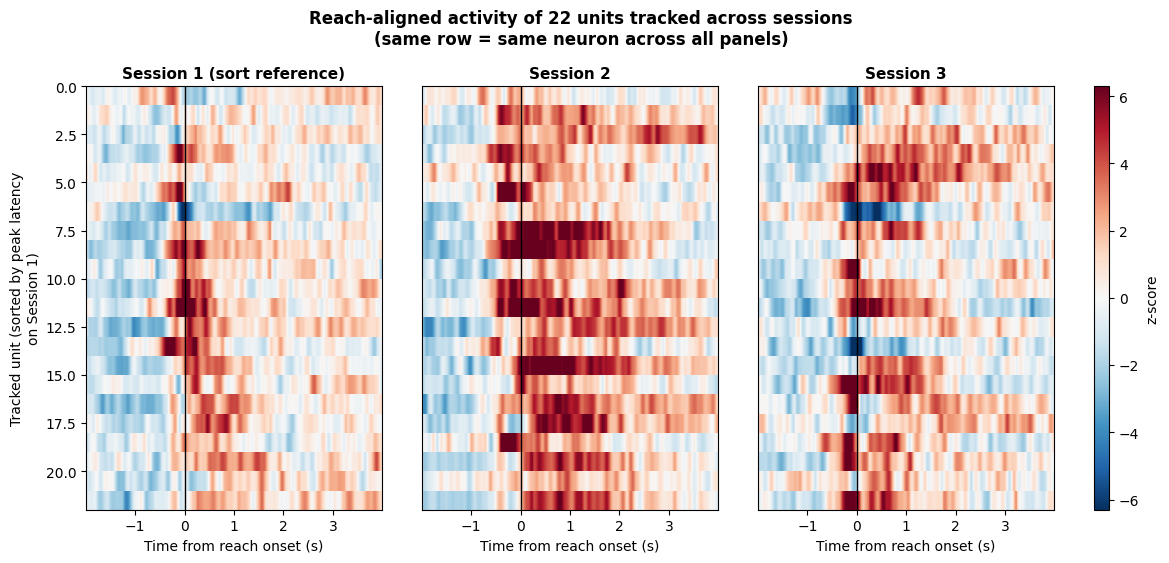


Saved → GRANT_tracked_heatmap.png/.pdf/.svg

===== Cross-day population sort consistency =====
(Spearman r between sessions' peak-latency rank orders)
  Session 1 vs Session 2: rho = +0.142, p = 0.527
  Session 1 vs Session 3: rho = -0.308, p = 0.163
  Session 2 vs Session 3: rho = +0.271, p = 0.222

===== Per-unit cross-day PSTH similarity =====
(Pearson r between each unit's z-PSTHs across sessions)
  Session 1 vs Session 2: median r = +0.561, mean = +0.470, n=22
  Session 1 vs Session 3: median r = +0.356, mean = +0.315, n=22
  Session 2 vs Session 3: median r = +0.458, mean = +0.374, n=22

===== DONE =====



In [7]:
# ============================================================
# CROSS-DAY HEATMAP — TRACKED UNITS, MATCHED ROW ORDER
# ============================================================
# For units tracked across all chosen focus sessions:
#   - Sort rows by peak latency on the REFERENCE session.
#   - Apply that same row order to every other session's heatmap.
#   - Use a shared symmetric color scale so panels are comparable.
# Preservation of the diagonal across sessions = preserved timing
# structure at the population level.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path

print("\n===== CROSS-DAY HEATMAP (matched row order) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
]
SESSION_LABELS = ["Session 1", "Session 2", "Session 3"]
OUTPUT_BASE = r"G:\Kevin\unit_matching"
REFERENCE_SESSION_IDX = 0    # which session defines the sort order (0-indexed)
# ------------------------------------------------------------

output_base = Path(OUTPUT_BASE)
n_sessions = len(SESSION_ANALYSIS_FOLDERS)
focus_names = [Path(sf).name for sf in SESSION_ANALYSIS_FOLDERS]

# ------------------------------------------------------------
# LOAD CHAINS + FILTER TO FULLY-TRACKED UNITS
# ------------------------------------------------------------
ch = np.load(output_base / "tracked_units_chains.npz", allow_pickle=True)
all_session_names = list(ch["session_names"])
units_by_session_full = ch["units_by_session"]

focus_cols = []
for fn in focus_names:
    if fn not in all_session_names:
        raise RuntimeError(f"Session {fn} not in chains. Re-run Cell Z.")
    focus_cols.append(all_session_names.index(fn))

units_focus_all = units_by_session_full[:, focus_cols]
keep_mask = (units_focus_all >= 0).all(axis=1)
units_focus = units_focus_all[keep_mask]
chain_rows = np.where(keep_mask)[0]
n_units = len(units_focus)
print(f"Tracked units present in all {n_sessions} sessions: {n_units}")

# ------------------------------------------------------------
# LOAD FINGERPRINTS, BUILD (n_units, n_bins) z-PSTH PER SESSION
# ------------------------------------------------------------
fps = []
for sf in SESSION_ANALYSIS_FOLDERS:
    fp = dict(np.load(Path(sf) / "fingerprints" / "unit_fingerprints.npz",
                      allow_pickle=True))
    fp["session_folder"] = str(sf)
    fps.append(fp)

def uidx(fp, uid):
    return int(np.where(fp["unit_ids"] == uid)[0][0])

# All sessions should be on the same 300-bin grid (Cell M-v3 standardized)
n_bins_check = [fp["reach_z_mean"].shape[1] for fp in fps]
if len(set(n_bins_check)) != 1:
    raise RuntimeError(f"PSTH bin counts differ across sessions: {n_bins_check}. "
                       "Re-run Cell M-v3 + Cell W with matched params.")
n_bins = n_bins_check[0]

# Time axis (centers) — pull from any session's reach arrays file
centers = np.load(
    Path(fps[0]["session_folder"]) / "qc" / "reach_good_in_trial_arrays.npz"
)["centers"]

# Build per-session (n_units, n_bins) matrices in the SAME row order
z_per_session = np.zeros((n_sessions, n_units, n_bins))
peak_lat_per_session = np.zeros((n_sessions, n_units))
for si, fp in enumerate(fps):
    for ui in range(n_units):
        uid = int(units_focus[ui, si])
        idx = uidx(fp, uid)
        z_per_session[si, ui] = fp["reach_z_mean"][idx]
        peak_lat_per_session[si, ui] = float(fp["reach_peak_lat"][idx])

# ------------------------------------------------------------
# SORT BY PEAK LATENCY ON REFERENCE SESSION
# ------------------------------------------------------------
ref_latencies = peak_lat_per_session[REFERENCE_SESSION_IDX]
order = np.argsort(ref_latencies)
print(f"Sorting rows by peak latency on {SESSION_LABELS[REFERENCE_SESSION_IDX]}")

# Shared symmetric color scale (98th percentile of |z| across all sessions)
vmax = np.percentile(np.abs(z_per_session), 98)
vmax = max(vmax, 3.0)
print(f"Color scale: ±{vmax:.1f}")

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig = plt.figure(figsize=(4.2 * n_sessions + 0.6, 5.5))
gs = GridSpec(1, n_sessions + 1, width_ratios=[1] * n_sessions + [0.05],
              wspace=0.18)

for si in range(n_sessions):
    ax = fig.add_subplot(gs[0, si])
    sorted_z = z_per_session[si][order]
    im = ax.imshow(sorted_z, aspect="auto",
                   extent=[centers[0], centers[-1], n_units, 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=1.0)
    ax.set_xlabel("Time from reach onset (s)")
    if si == 0:
        ax.set_ylabel(f"Tracked unit (sorted by peak latency\non {SESSION_LABELS[REFERENCE_SESSION_IDX]})")
    else:
        ax.set_yticks([])
    title_extra = " (sort reference)" if si == REFERENCE_SESSION_IDX else ""
    ax.set_title(f"{SESSION_LABELS[si]}{title_extra}", fontsize=11, fontweight="bold")

# Shared colorbar
cax = fig.add_subplot(gs[0, -1])
plt.colorbar(im, cax=cax, label="z-score")

plt.suptitle(f"Reach-aligned activity of {n_units} units tracked across sessions\n"
             f"(same row = same neuron across all panels)",
             fontsize=12, fontweight="bold", y=1.02)

out_base = output_base / "GRANT_tracked_heatmap"
plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.pdf", bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.svg", bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved → {out_base.name}.png/.pdf/.svg")

# ------------------------------------------------------------
# QUANTITATIVE COMPANIONS (printed, not in the figure)
# ------------------------------------------------------------
# Spearman correlation of peak latencies across pairs (rank-based,
# robust to outliers — better than Pearson here)
from scipy.stats import spearmanr
print(f"\n===== Cross-day population sort consistency =====")
print("(Spearman r between sessions' peak-latency rank orders)")
for a in range(n_sessions):
    for b in range(a + 1, n_sessions):
        rho, p = spearmanr(peak_lat_per_session[a], peak_lat_per_session[b])
        print(f"  {SESSION_LABELS[a]} vs {SESSION_LABELS[b]}: rho = {rho:+.3f}, p = {p:.3g}")

# Row-by-row correlation: does each unit's PSTH shape correlate across sessions?
print(f"\n===== Per-unit cross-day PSTH similarity =====")
print("(Pearson r between each unit's z-PSTHs across sessions)")
for a in range(n_sessions):
    for b in range(a + 1, n_sessions):
        rs = []
        for ui in range(n_units):
            za = z_per_session[a, ui]; zb = z_per_session[b, ui]
            if za.std() > 0 and zb.std() > 0:
                rs.append(np.corrcoef(za, zb)[0, 1])
        rs = np.array(rs)
        print(f"  {SESSION_LABELS[a]} vs {SESSION_LABELS[b]}: "
              f"median r = {np.median(rs):+.3f}, mean = {rs.mean():+.3f}, n={len(rs)}")

print("\n===== DONE =====\n")